# ZeroJudge 5 題練習版 Notebook

使用方式：
1. 先讀「題目重點」。
2. 回答「思考問題」。
3. 再完成 `TODO` 程式碼。
4. 最後用範例測試確認輸出是否正確。

---
# 1. a181 逆逆向思考：Trie 字典樹

## 題目重點
輸入有多組測資。每組第一行是 `N`，接下來有 `N` 個字串。請把字串放入 Trie，最後依照 ASCII 由小到大輸出 Trie 裡的字串。

Trie 可以想成「把共同開頭的字串共用同一條路」。例如：`tea`、`ted`、`ten` 都會共用 `t -> e`。

## 學習目標
- 會用巢狀 dictionary 表示樹狀結構。
- 會把字串逐字插入 Trie。
- 會用 DFS 走訪 Trie。
- 會使用 `sorted()` 讓輸出順序固定。

## 思考問題
1. 為什麼 Trie 可以節省重複的字首？
2. 如果一個字串已經結束，要怎麼在節點上做記號？
3. 為什麼輸出時要對每一層的字元排序？
4. 如果輸入有很多組測資，要怎麼讀到 EOF？

## 範例輸入
```text
8
A
to
tea
ted
ten
i
in
inn
```

## 預期輸出
```text
A
i
in
inn
tea
ted
ten
to
```


In [ ]:
# a181 練習區：請完成 TODO

END = ""  # 特殊記號：代表這裡是一個完整字串的結尾


def insert(root, word):
    """把一個字串放進 Trie。"""
    node = root
    for ch in word:
        # TODO 1：如果 ch 還不在 node 裡，建立一個新的空 dictionary
        
        # TODO 2：往下一層走
        
    # TODO 3：字串結束，在目前 node 放入 END 記號
    


def collect(node, path, answer):
    """依照 ASCII 順序，把 Trie 裡面的完整字串收集出來。"""
    # TODO 4：如果這個節點有 END，代表 path 是一個完整字串，要加入 answer
    

    # TODO 5：依照 sorted(node.keys()) 的順序走訪下一層
    # 注意：遇到 END 不要繼續往下走
    


def solve(data):
    lines = data.splitlines()
    i = 0
    outputs = []

    while i < len(lines):
        if lines[i].strip() == "":
            i += 1
            continue

        n = int(lines[i])
        i += 1
        words = lines[i:i+n]
        i += n

        root = {}
        # TODO 6：把每個 word 插入 Trie
        

        answer = []
        # TODO 7：從 root 開始收集答案
        

        outputs.extend(answer)

    return "
".join(outputs)


sample = """8
A
to
tea
ted
ten
i
in
inn
"""
print(solve(sample))


---
# 2. f581 圓環出口：前綴和 + 二分搜尋

## 題目重點
有 `n` 個房間排成一圈，從房間 `i` 會走到 `(i+1) mod n`。進入房間 `i` 可以得到 `p[i]` 分。

每個任務需要累積 `q` 分。完成任務後，會停在「最後拿分房間的下一個房間」。一開始在房間 `0`，請輸出所有任務完成後的位置。

## 學習目標
- 會把圓形陣列變成 `p + p`。
- 會用前綴和快速計算區間總和。
- 會用二分搜尋找第一個達標的位置。
- 會理解 `% n` 回到圓環位置。

## 思考問題
1. 為什麼圓形房間可以用 `p + p` 變成直線？
2. 前綴和 `prefix[k]` 代表什麼意思？
3. 如果目前在 `pos`，需要 `q` 分，目標前綴和是多少？
4. 找到 `k` 之後，為什麼新位置是 `k % n`？

## 範例輸入 1
```text
7 3
2 1 5 4 3 5 3
8 9 12
```
預期輸出：`4`

## 範例輸入 2
```text
4 3
1 3 5 7
4 2 2
```
預期輸出：`0`


In [ ]:
5 % 2

# 13 o'clock -> 13 mod(12) => 1
# n = 4 -> 初始 3 -> (3 + 1) % 4 = 0
# 房間分數：p; 任務分數：q
# 2 -> 3 -> 4 -> 5 -> 6 -> 0 -> 1
# p 累加超過 q 則停下來

1

n = 7
m = 3

p = [2 1 5 4 3 5 3]
p_double = [2 1 5 4 3 5 3 2 1 5 4 3 5 3] -> [0 3 8 12 ]
q = [8 9 12]

結果 -> 4

第一個任務 8:

2 + 1 + 5 = 8 -> i = 2 % 7

第二個任務 9:

4 + 3 + 5 = 12 -> i = 5 % 7

第三個任務 12:

3 + 2 + 1 + 5 + 4 -> i = 10 % 7 


最後更新 -> 3 + 1 = 4


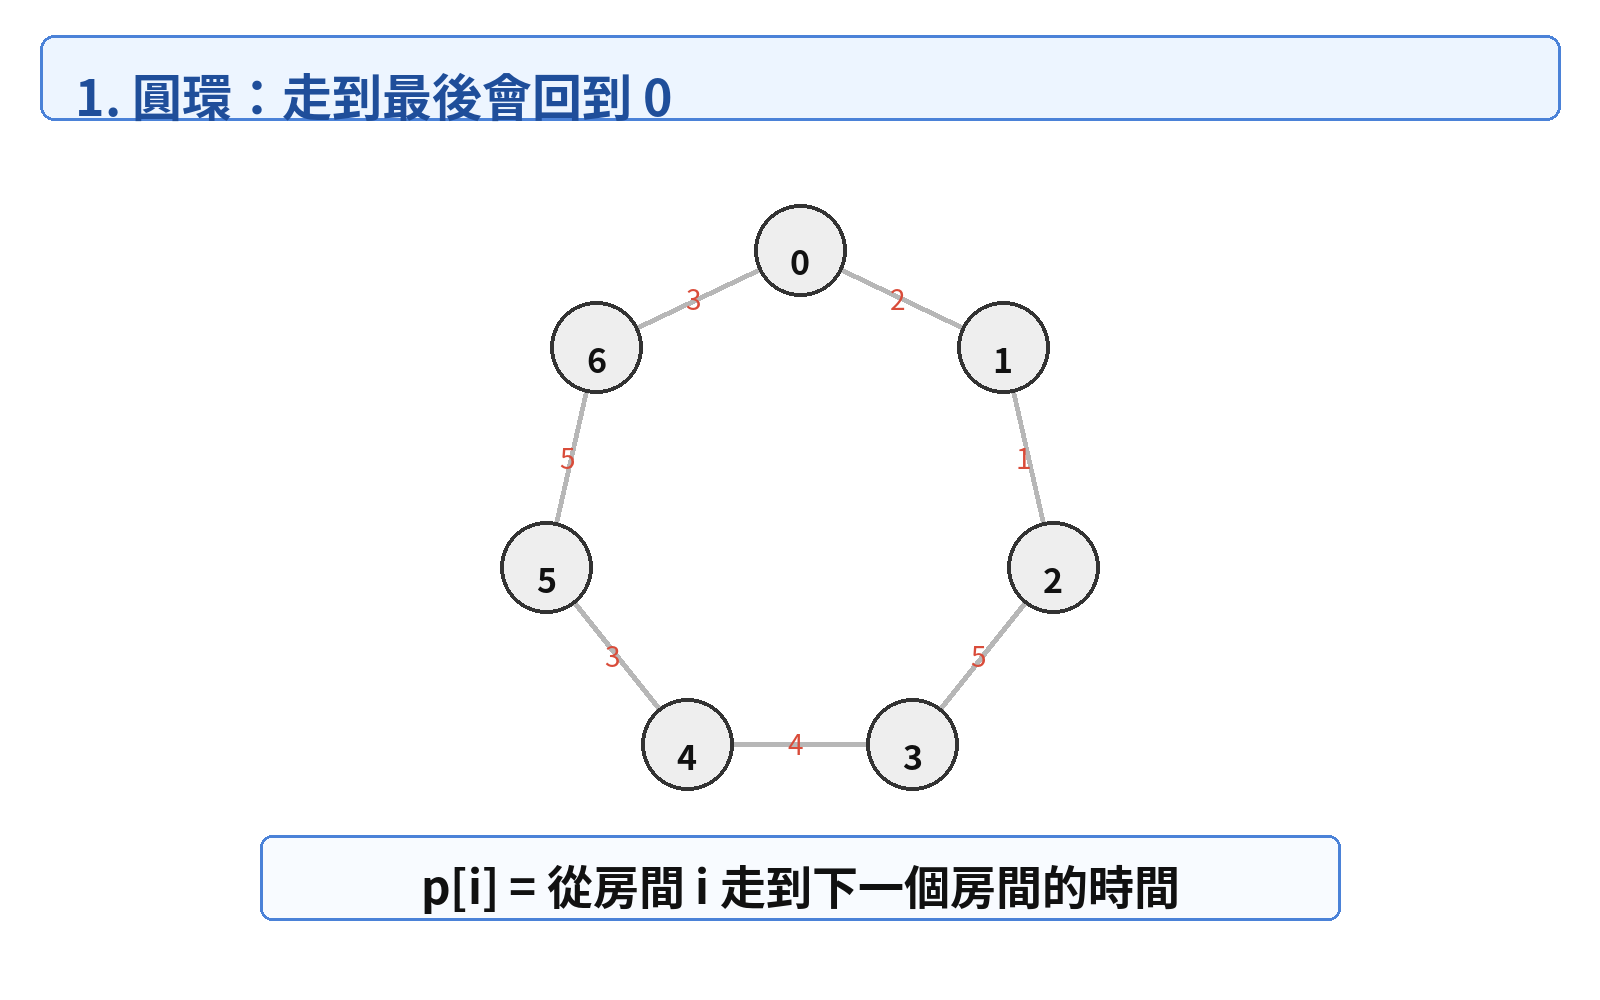

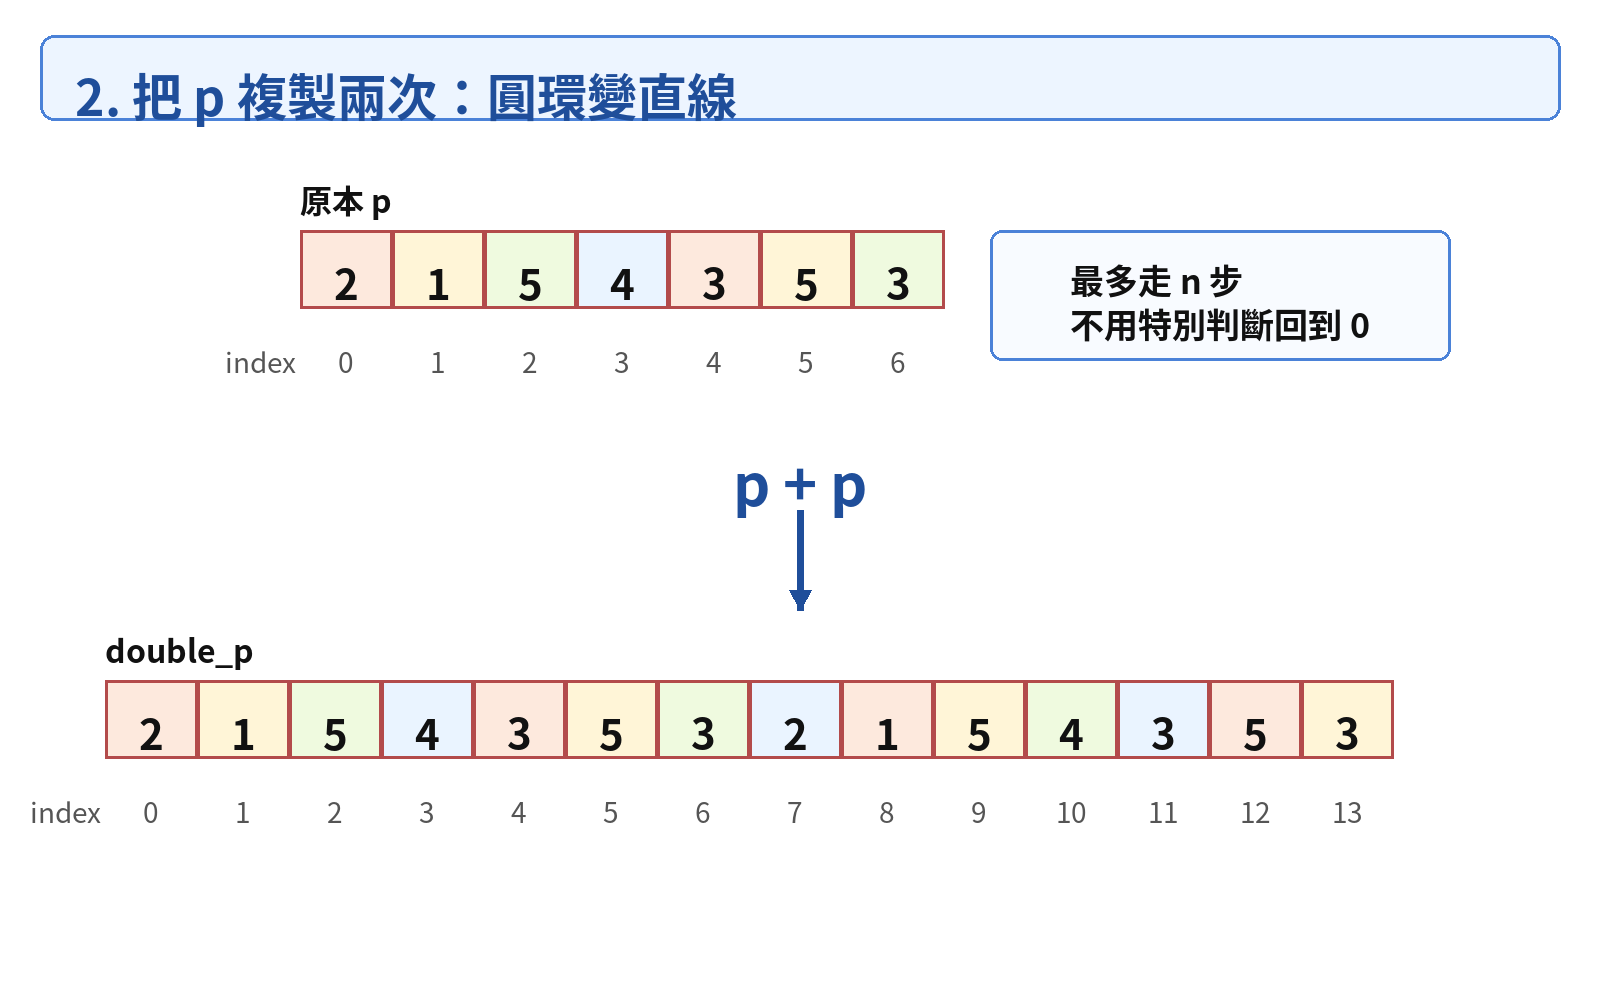

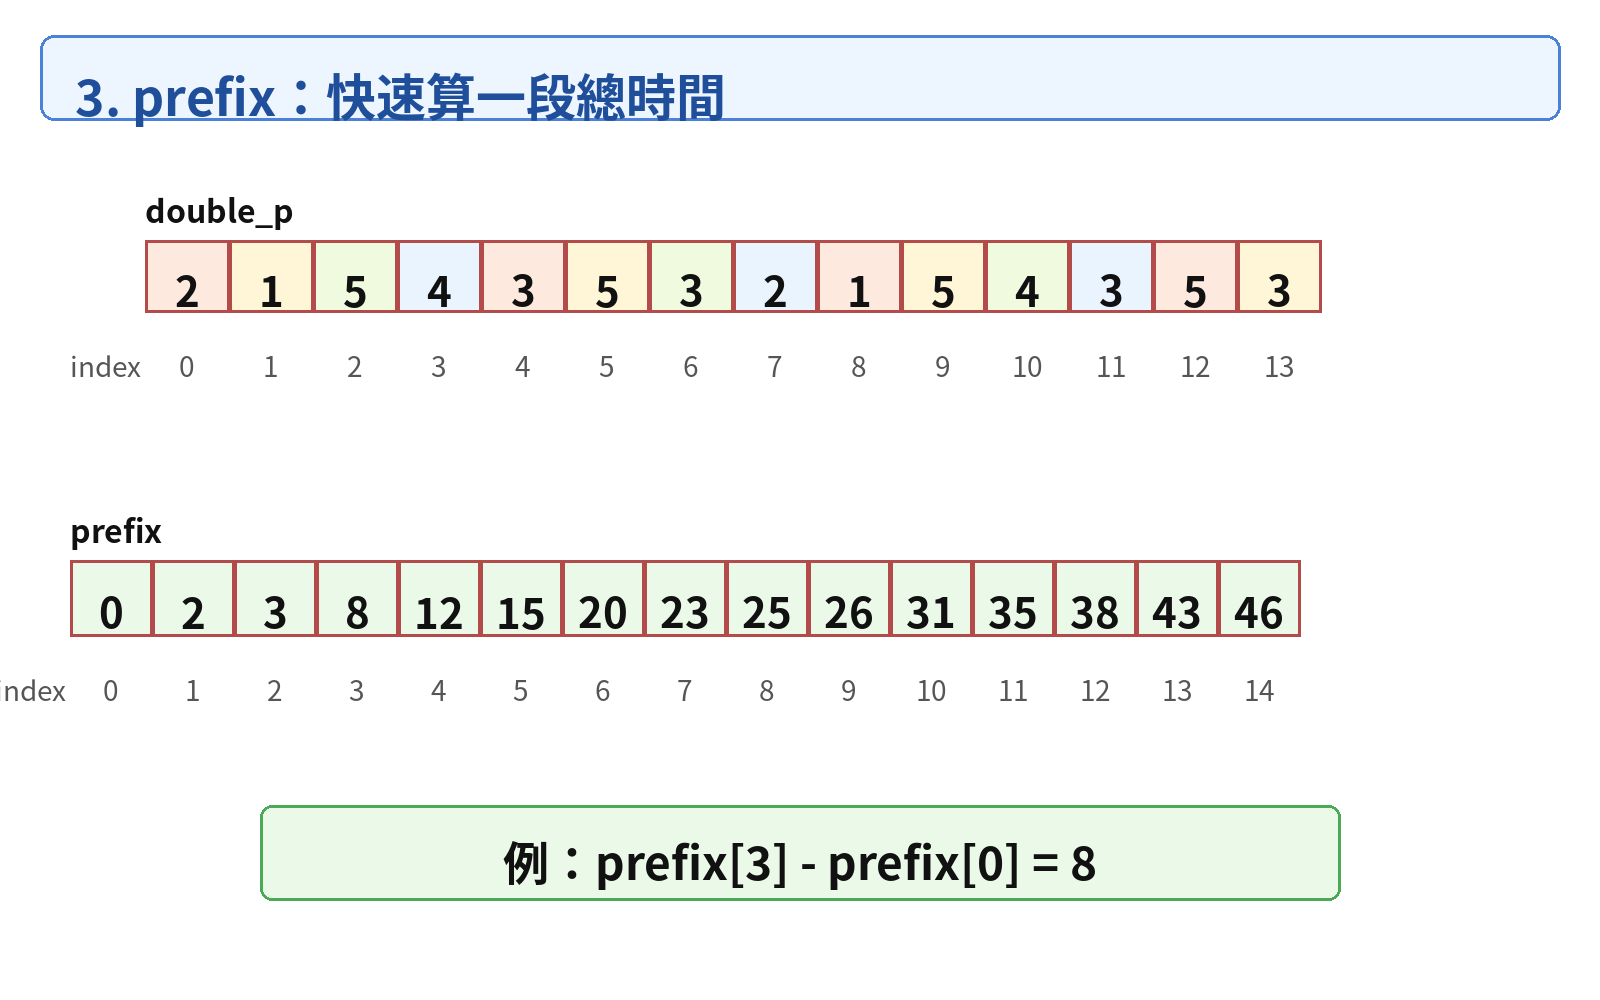

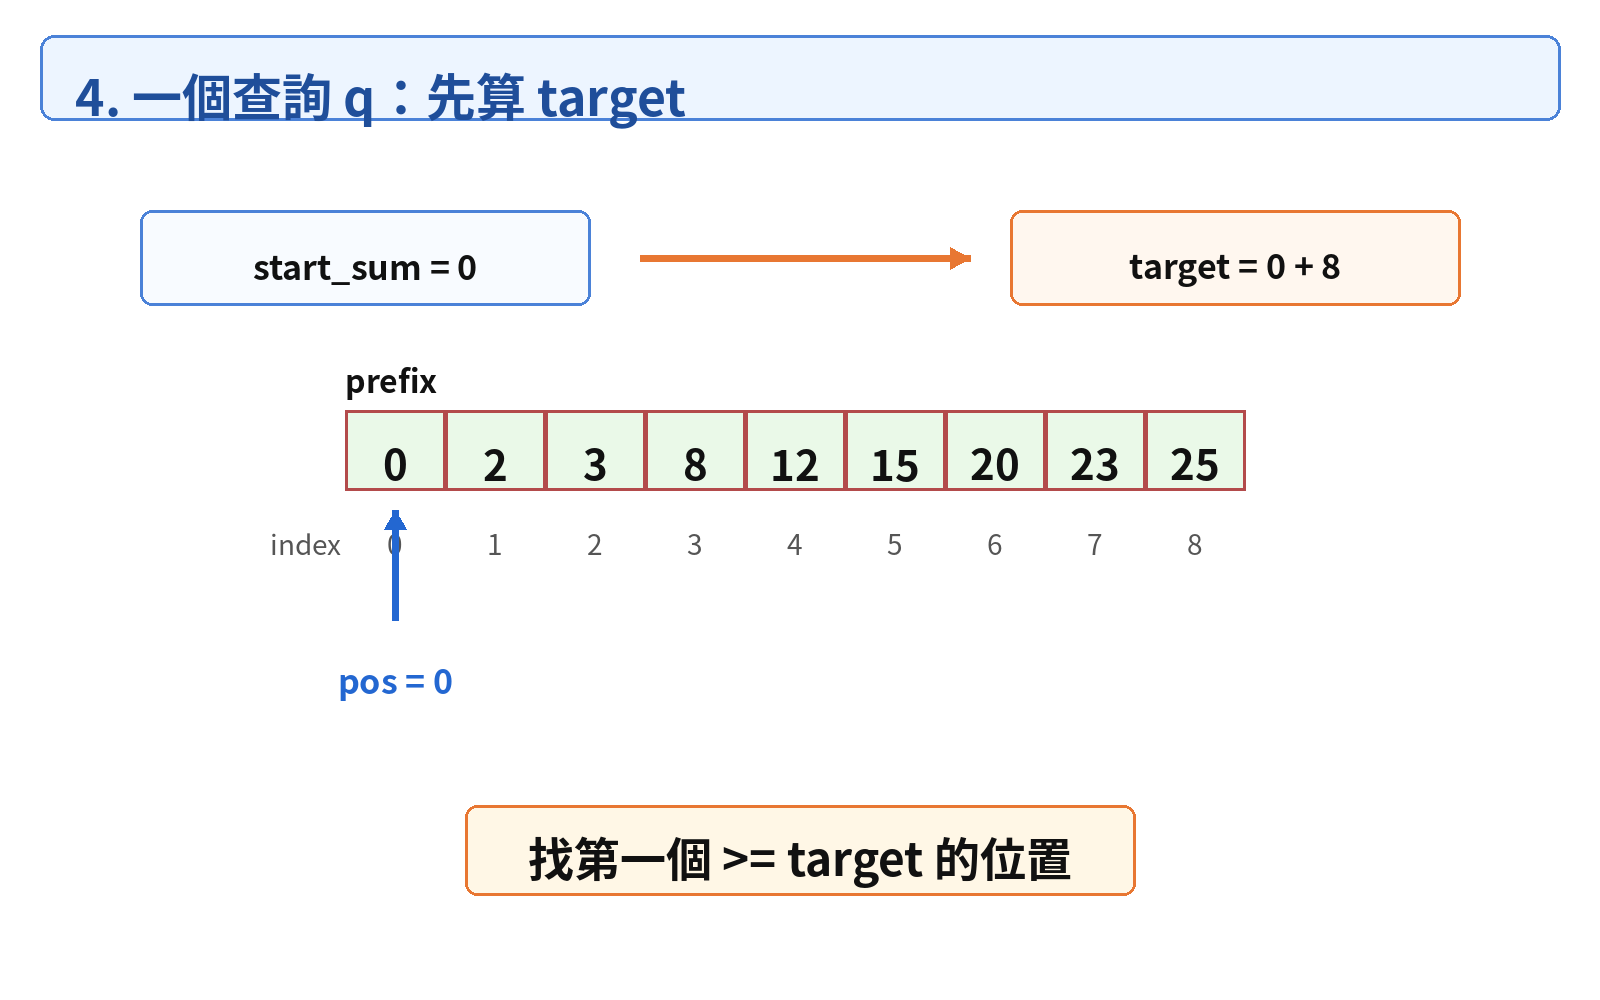

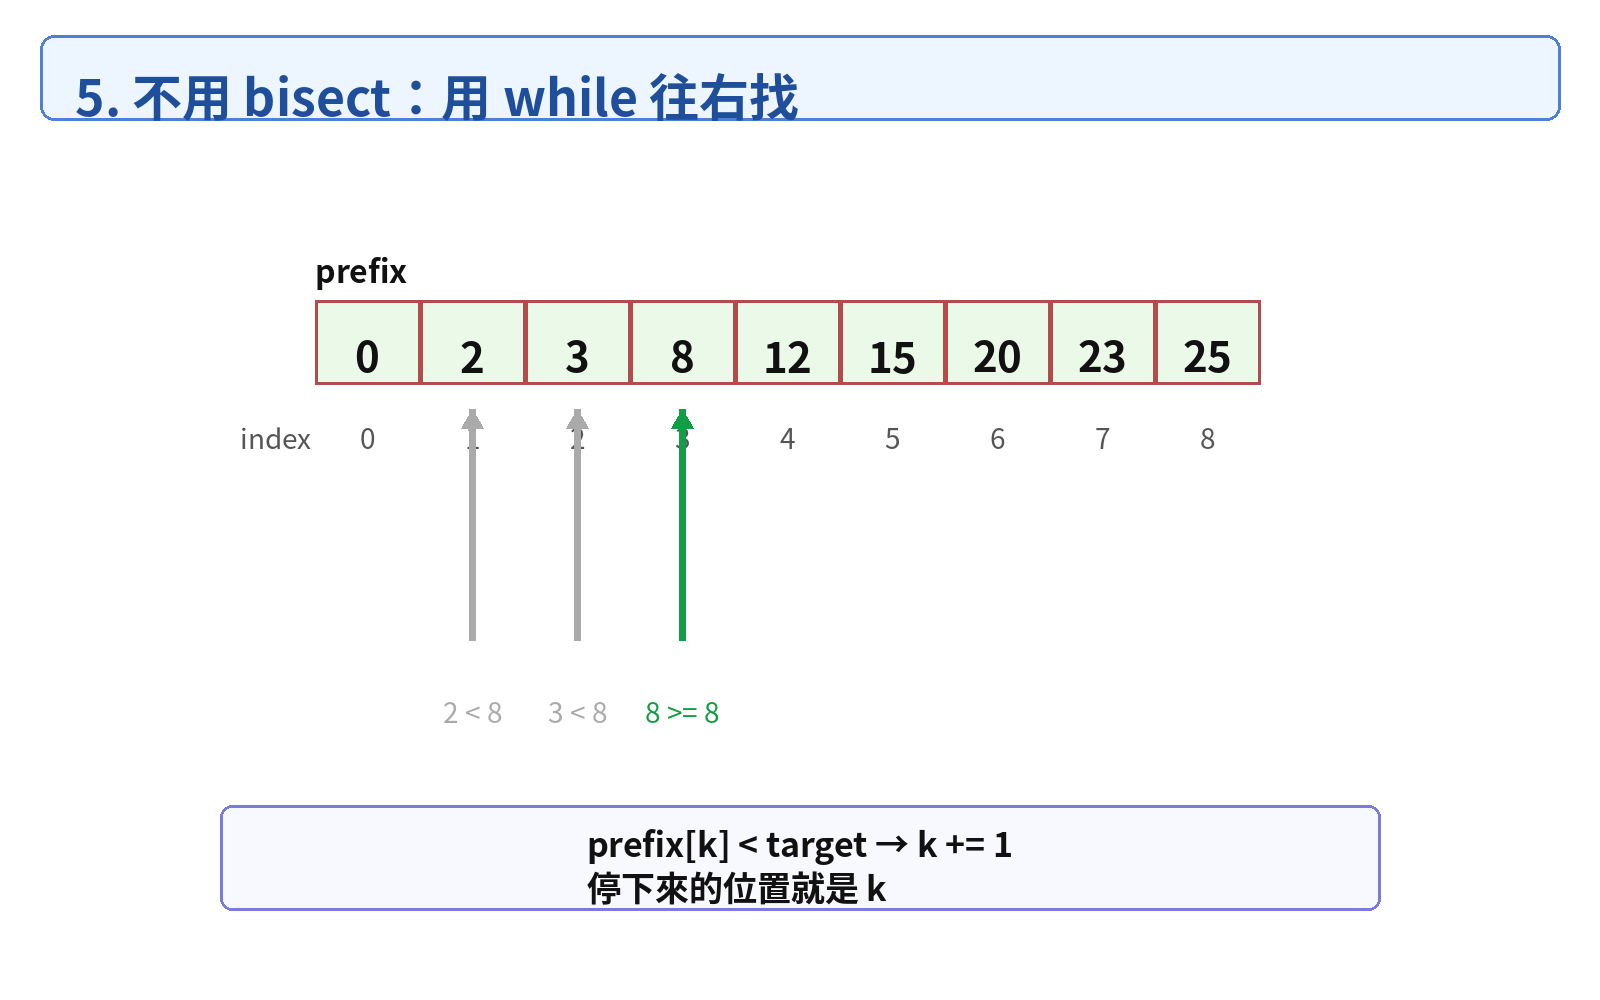

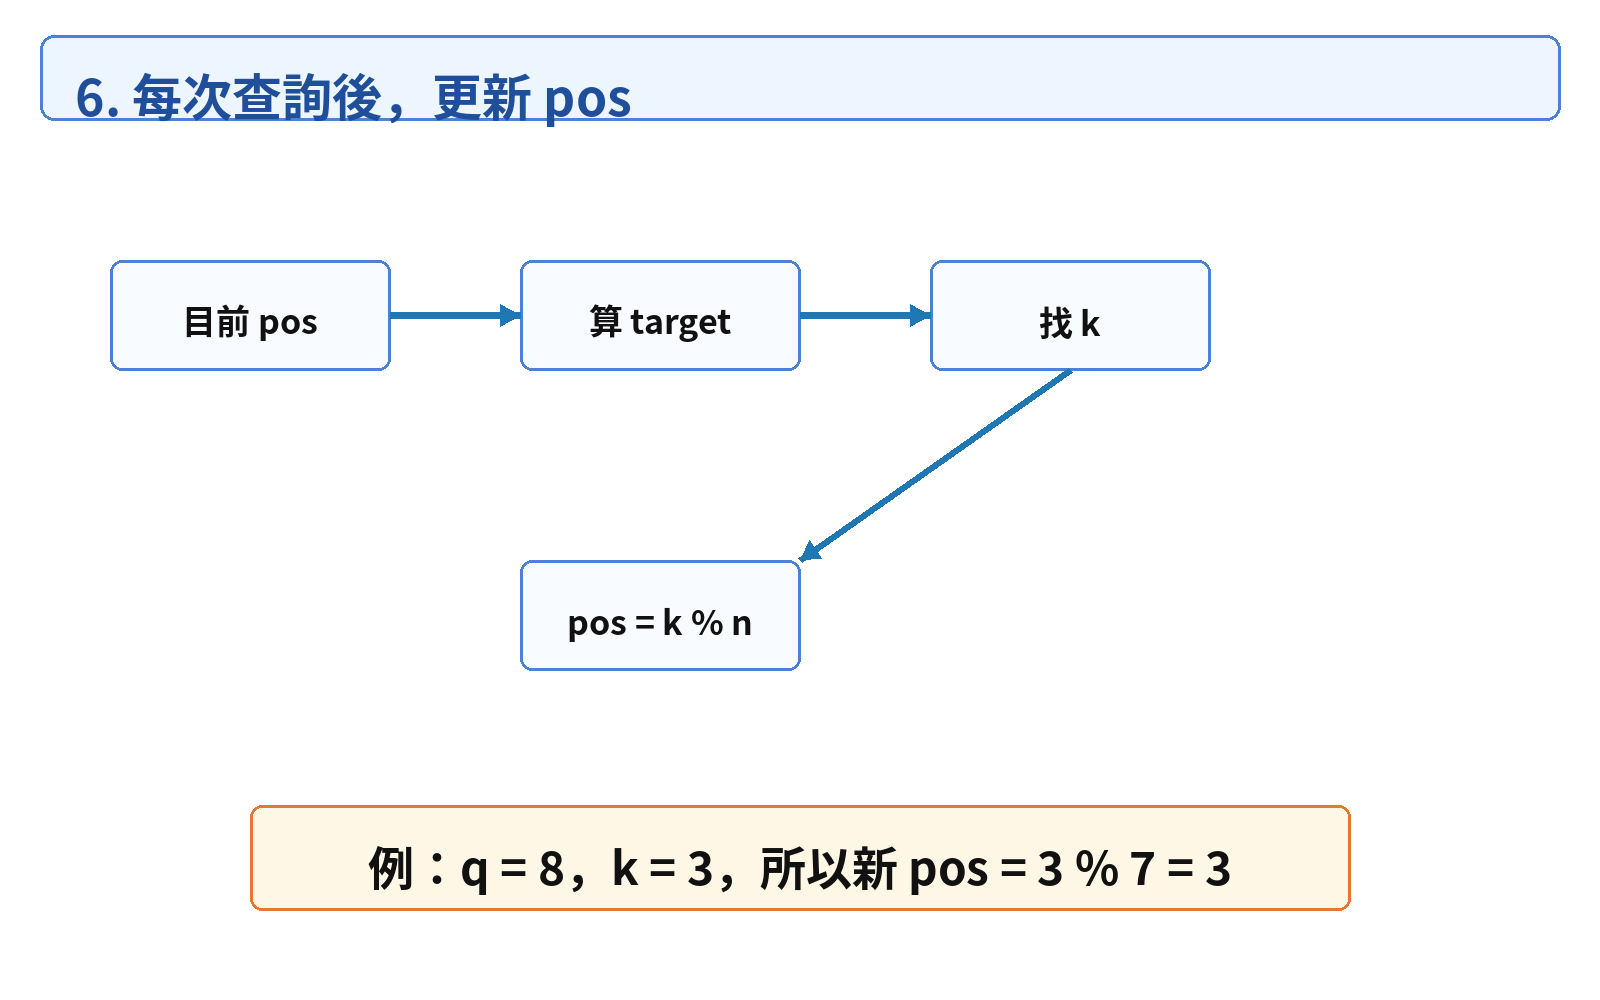

In [3]:
# f581 練習區：請完成 TODO
from bisect import bisect_left


def solve(data):
    nums = list(map(int, data.split()))
    idx = 0

    n = nums[idx]
    m = nums[idx + 1]
    idx += 2

    p = nums[idx:idx + n]
    idx += n
    qs = nums[idx:idx + m]

    # TODO 1：把 p 複製兩次，處理圓環問題
    double_p = p + p

    # TODO 2：建立 prefix，prefix[0] = 0
    prefix = [0]
    for x in double_p:
        prefix.append(prefix[-1] + x)
    print(prefix)

    pos = 0
    for q in qs:
        start_sum = prefix[pos]
        target = start_sum + q

        # TODO 4：用 bisect_left 找第一個 prefix[k] >= target 的位置 k
        k = pos + 1 

        # TODO 5：任務完成後停在下一個房間，也就是 k % n
        while k <=  pos+n and prefix[k] < target:
            k += 1

        pos = k % n 

    return str(pos)


print(solve("""7 3
2 1 5 4 3 5 3
8 9 12
"""))  # 預期：4
print(solve("""4 3
1 3 5 7
4 2 2
"""))  # 預期：0


[0, 2, 3, 8, 12, 15, 20, 23, 25, 26, 31, 35, 38, 43, 46]
4
[0, 1, 4, 9, 16, 17, 20, 25, 32]
0


---
# 3. e313 最少相異字母：set + 自訂排序

## 題目重點
給 `N` 個只含大寫 `A~Z` 的字串。要找出「相異字母數量最少」的字串。如果有多個一樣少，選字典序最小的字串。

例如：
- `ABBCAAB` 的相異字母是 `{A, B, C}`，數量是 3。
- `AABBACC` 的相異字母是 `{A, B, C}`，數量是 3。
- `AAPPCCSS` 的相異字母是 `{A, P, C, S}`，數量是 4。

前兩個一樣少，再比字典序，答案是 `AABBACC`。

## 學習目標
- 會使用 `set()` 去除重複字元。
- 會用 `len(set(s))` 計算相異字母數量。
- 會理解 tuple 排序：先比第一項，再比第二項。

## 思考問題
1. `set("ABBCAAB")` 會剩下哪些字母？
2. 為什麼 `(相異字母數量, 字串本身)` 可以當作比較標準？
3. 如果兩個字串相異字母數量一樣，Python 會怎麼比字串？

## 範例輸入
```text
3
ABBCAAB
AABBACC
AAPPCCSS
```

## 預期輸出
```text
AABBACC
```


In [3]:
# e313 練習區：請完成 TODO

def solve(data):
    lines = data.splitlines()
    n = int(lines[0])
    words = [lines[i].strip() for i in range(1, n + 1)]

    best = min(words, key=lambda w: (len(set(w)), w))

    return best


print(solve("""3
ABBCAAB
AABBACC
AAPPCCSS
"""))  # 預期：AABBACC


AABBACC


In [5]:
a = "ABBCAAB"
list_a = list(a)
print(list_a)
print(set(list_a))

['A', 'B', 'B', 'C', 'A', 'A', 'B']
{'B', 'A', 'C'}


---
# 4. q368 阿克曼函數：函式與遞迴

## 題目重點
輸入 `m, n`，計算阿克曼函數 `A(m, n)`。

定義如下：
```text
A(m, n) = n + 1                         if m == 0
A(m, n) = A(m - 1, 1)                   if m > 0 and n == 0
A(m, n) = A(m - 1, A(m, n - 1))         if m > 0 and n > 0
```

題目限制：`0 <= m <= 3`，`0 <= n <= 11`。

## 學習目標
- 會把數學定義轉成 Python 函式。
- 會判斷遞迴的終止條件。
- 會理解「函式裡面再呼叫函式」的執行方式。

## 思考問題
1. 哪一行是最重要的終止條件？
2. `A(1, 2)` 會先呼叫誰？
3. 為什麼 `m` 和 `n` 如果太大，遞迴會很慢？
4. 本題 `m <= 3`，你可以用遞迴直接寫，也可以推公式。哪一種比較好懂？

## 範例輸入 1
```text
1 2
```
預期輸出：`4`

## 範例輸入 2
```text
3 11
```
預期輸出：`16381`


In [ ]:
# q368 練習區：請完成 TODO

def A(m, n):
    # TODO 1：如果 m == 0，回傳 n + 1
    
    # TODO 2：如果 m > 0 且 n == 0，回傳 A(m - 1, 1)
    
    # TODO 3：如果 m > 0 且 n > 0，回傳 A(m - 1, A(m, n - 1))
    


def solve(data):
    m, n = map(int, data.split())
    return str(A(m, n))


print(solve("1 2"))   # 預期：4
print(solve("3 11"))  # 預期：16381


---
# 5. g277 幸運數字：分治法 + 區間總和

## 題目重點
給一個數列，所有數字都不相同。要找出整個區間中的「幸運數字」。

規則：
1. 如果區間只剩一個數字，這個數字就是幸運數字。
2. 如果區間有多個數字，先找出區間中最小數字的位置 `m`。
3. 用 `m` 把區間切成左邊 `[L, m-1]` 和右邊 `[m+1, R]`。
4. 比較左右兩邊的總和，往總和比較大的那邊繼續找。
5. 如果左右總和一樣，往右邊找。
6. 空區間總和是 0。

## 學習目標
- 會使用前綴和快速計算區間總和。
- 會用遞迴或 while 逐步縮小區間。
- 會理解「每次根據規則選左邊或右邊」。

## 思考問題
1. 區間總和為什麼可以用前綴和快速算？
2. 為什麼每一輪要先找最小值位置？
3. 如果左邊總和和右邊總和相等，題目規定要去哪邊？
4. 這題直接每次用 `min()` 找最小值，對大資料可能會慢；但對初學練習可以先理解規則。

## 範例輸入 1
```text
5
4 2 3 1 5
```
預期輸出：`4`

## 範例輸入 2
```text
8
3 9 4 5 1 6 2 8
```
預期輸出：`9`


In [ ]:
# g277 練習區：請完成 TODO
# 這裡先給國中生容易理解的版本：每次在區間中尋找最小值位置。
# 大資料若要更快，可以再學進階資料結構，例如 Cartesian Tree 或 Segment Tree。


def range_sum(prefix, L, R):
    """回傳 a[L] 到 a[R] 的總和；如果是空區間，回傳 0。"""
    if L > R:
        return 0
    # TODO 1：用 prefix 計算區間總和
    return None


def solve(data):
    nums = list(map(int, data.split()))
    n = nums[0]
    a = nums[1:]

    # TODO 2：建立前綴和 prefix
    prefix = [0]
    # for x in a:
    #     ...

    L, R = 0, n - 1

    while L < R:
        # TODO 3：找出 a[L:R+1] 中最小值的位置 m
        m = None

        # TODO 4：計算左邊總和與右邊總和
        left = None
        right = None

        # TODO 5：如果 left > right，往左邊；否則往右邊
        

    return str(a[L])


print(solve("""5
4 2 3 1 5
"""))  # 預期：4
print(solve("""8
3 9 4 5 1 6 2 8
"""))  # 預期：9


---
# 學生完成後可以檢查的重點

- 程式是否可以處理範例測資？
- 變數名稱是否清楚？
- 是否有把「題目規則」變成「程式步驟」？
- 是否知道每一個 TODO 在做什麼？
- 如果出錯，先用小範例手算，再對照程式每一步。
